## 3. Тренування YOLOv8n

### Підготовка до тренування

**YOLOv8n** показав `batch=8`, `imgsz=640` де на першій епосі, `GPU_mem` тримався в межах близько 1-2 Gb

Врешті було прийнято рішення поставити **80 епох**. Загалом VisDrone важкий з великою кількістю маленьких деталей, тож дати час і більше епох модельці навчитись було валідним (використано early stopping на випадок повтору результатів). Відпрацювали всі 80 епох (близько 2.5 год), де mAP до кінця ще підростав, зупинятись раніше сенсу не було. Після 5-10 епох параметр loss вже падав, mAP був > 0, тож все рухалось добре.

Через CLI використано команду:
```bash
yolo detect train data=data/visdrone.yaml model=yolov8n.pt epochs=80 imgsz=640 batch=8 patience=20 device=0 workers=2 project=runs/detect name=visdrone_yolov8n
```

### Вийшло

Найкращі ваги: `runs/detect/visdrone_yolov8n/weights/best.pt`

На валідації (епоха 80): **mAP50 близько 0.30**, **precision близько 0.43**, **recall до 0.33**
модель щось знаходить, але багато пропускає, це може бути очікувано для VisDrone на nano

По графіку ( `results.png` ): mAP ріс з 0.10 до 0.30, найбільший приріст був до 60-ої епохи, далі вже повільніше.
Loss і train, і val падали без різкого розходження, на перетренування не схоже.

По класах картина така сама, як передбачали на EDA: **car** тягне все (mAP50 *0.73*), а **bicycle** (*0.06*) і **awning-tricycle** (*0.10*) майже не вчаться, на самому датасеті було мало прикладів і об'єкти дрібні. `people` і `pedestrian` теж плутаються між собою.

![results.png](../notebooks/photo/results.png)

### Динаміка метрик

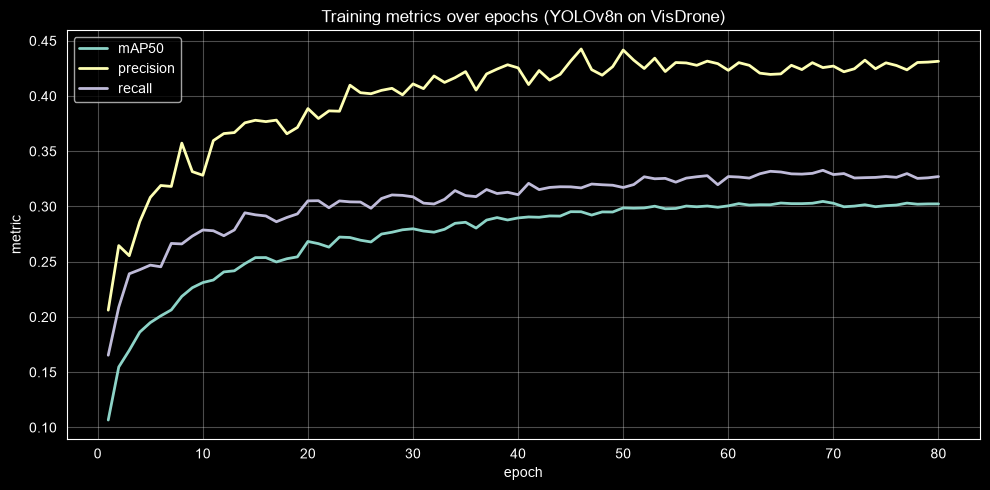

,epoch,metrics/mAP50(B),metrics/precision(B),metrics/recall(B)
75,76,0.30131,0.42764,0.32642
76,77,0.30306,0.42370,0.32979
77,78,0.30209,0.43036,0.32544
78,79,0.30235,0.43071,0.32596
79,80,0.30238,0.43144,0.32709


In [6]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../runs/detect/runs/detect/visdrone_yolov8n").resolve()
results_csv = RESULTS_DIR / "results.csv"

if not results_csv.exists():
    raise FileNotFoundError(f"Not found: {results_csv}")

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50", linewidth=2)
ax.plot(df["epoch"], df["metrics/precision(B)"], label="precision", linewidth=2)
ax.plot(df["epoch"], df["metrics/recall(B)"], label="recall", linewidth=2)
ax.set_xlabel("epoch")
ax.set_ylabel("metric")
ax.set_title("Training metrics over epochs (YOLOv8n on VisDrone)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(df[["epoch", "metrics/mAP50(B)", "metrics/precision(B)", "metrics/recall(B)"]].tail())